# Simulate Populations with Asexual Reproduction
## Part 2

In the previous section, we created a simulation that models the population growth of a unicellular organism that reproduces asexually.

https://vlab.amrita.edu/?sub=3&brch=65&sim=174&cnt=1 provides functions to discrete and continuous population growth, let's see if they work for the simulation.



In [17]:
# Import required modules
import numpy as np
import matplotlib.pyplot as plt
from fractions import Fraction
import random
import collections
import pandas as pd
import math

In [18]:
starting_pop = 1
repro_chance = 0.2
death_chance = 0.1

n_periods = 50
r_runs = 1000

In [19]:
def discrete_pop(starting_pop, repro_chance, death_chance, end_time):
    """ Exponential population growth model for discrete breeding season"""

    r = 1 + (repro_chance - death_chance)
    return pd.Series([r**t*starting_pop for t in range(end_time + 1)])

def continuous_pop(starting_pop, repro_chance, death_chance, end_time):
    """ Exponential population growth model for continuous breeding season"""

    r = repro_chance - death_chance
    return pd.Series([starting_pop * math.exp(r*t) for t in range(end_time + 1)])


First we can print out the predicted population after `n_periods` from the discrete and continuous functions. 

In [20]:
# Predicted population growth using discrete function
pred_disc = discrete_pop(starting_pop, repro_chance, death_chance, n_periods)
pred_disc.iloc[-1]

117.39085287969579

In [21]:
# Predicted population growth using continuous function
pred_cont = continuous_pop(starting_pop, repro_chance, death_chance, n_periods)
pred_cont.iloc[-1]

148.4131591025766

Let's verify whether these functions approximately predict the population by comparing them to the simulation from part 1.

In [25]:
def trial(chance):
    """ Returns the boolean outcome of a trial given it's chance of success."""

    return random.random() <= chance


class entity():
    """ The entity object represents a live entity."""
    
    def __init__(self):
        self.period = 0
    
    def __repr__(self):
        return str(self.period)

    def __call__(self):
        self.period += 1
        return self


class environment():
    """ The environment tracks the population and parameters of the simulation."""

    def __init__(self, repro_chance, death_chance, starting_pop):
        self.repro_chance = repro_chance
        self.death_chance = death_chance
        self.starting_pop = starting_pop

        self.population = [entity() for p in range(0, starting_pop)]
        self.history = [starting_pop]
        self.mortuary = collections.Counter()

    def __call__(self):

        # Simulate period
        survive, expire, births = [], [], []
        # First determine which entities expired by end of previous period.
        for e in self.population:
            if trial(self.death_chance):
               expire.append(e().period) 
            else:
                survive.append(e())
                # Determine if the entity reproduced by end of current period.
                if trial(self.repro_chance):
                    births.append(entity())            

        # Finally, update attributes
        self.population = survive + births
        self.mortuary.update(expire)
        self.history.append(len(self.population))

Population at time step 50

    Simulation Mean:  99.79
          pred_disc: 117.39
          pred_cont: 148.41


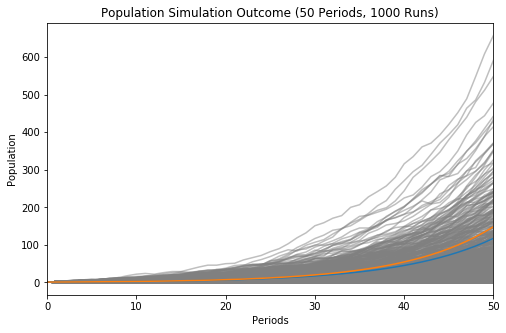

In [37]:
def run_sim(starting_pop, repro_chance, death_chance, n_periods, r_runs):
    """ Run simulation of environment for n periods and repeat r times, then plot the result"""

    # Set up plot
    fig, ax = plt.subplots(figsize=(8,5))
    ax.set(
        title=f"Population Simulation Outcome ({n_periods} Periods, {r_runs} Runs)",
        xlabel="Periods",
        ylabel="Population",
        xlim=(0, n_periods)
    )

    # Run simulation n times with r repeats.
    last = []
    for r in range(r_runs):
        env = environment(repro_chance, death_chance, starting_pop)
        for period in range(0, n_periods):
            env()
        last.append(env.history[-1])
        ax.plot(env.history, color=[.5, .5, .5, .5])

    ax.plot(pred_disc)
    ax.plot(pred_cont)
    last = [x for x in last if x > 0]

    print(f"Population at time step {n_periods}\n")
    print(f"{'Simulation Mean:':>20} {sum(last)/len(last):>6.2f}")
    print(f"{'pred_disc:':>20} {pred_disc.iloc[-1]:>6.2f}")
    print(f"{'pred_cont:':>20} {pred_cont.iloc[-1]:>6.2f}")


# Run the simulation
run_sim(starting_pop, repro_chance, death_chance, n_periods, r_runs)

To obtain the Simulation Mean printed out in the table above, we removed all extinct populations. Running the sample with 100,000 trials revelas that the two models are not quite accurate but generally pretty close.